In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = r'E:\Thesis\thesis_code\data\rp\rp_ethernet_packets_test_100.mat'

In [4]:
def load_ethernet_data(file_path, num_packets=10):
    """Loads metadata and a specific number of raw packets."""
    with h5py.File(file_path, 'r') as f:
        # Load metadata
        metadata = f['metadata']
        params = {
            'sample_rate': metadata['sample_rate'][0][0],
            'trigger_level': metadata['trigger_level'][0][0],
            'record_length': metadata['record_length'][0][0]
        }
        # Load only the first N packets to save memory
        packets = np.array(f['packets'][:num_packets, :])
    return packets, params

In [5]:
packets, params = load_ethernet_data(file_path, num_packets=1000)
print(f"Loaded {len(packets)} packets with parameters: {params}")

Loaded 100 packets with parameters: {'sample_rate': np.float64(125000000.0), 'trigger_level': np.float64(1.5), 'record_length': np.float64(16384.0)}


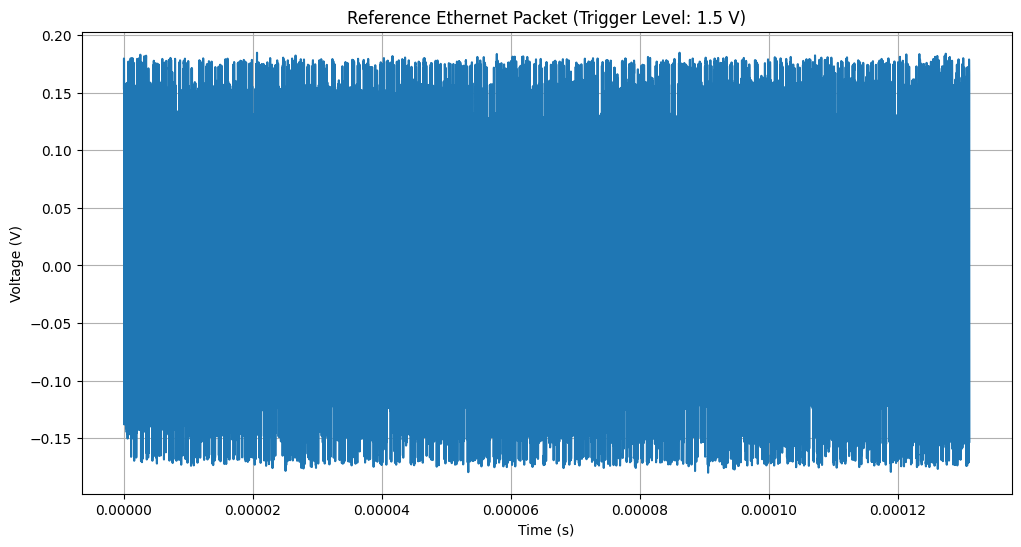

In [6]:
time_axis = np.arange(params['record_length']) / params['sample_rate']

plt.figure(figsize=(12,6))
plt.plot(time_axis, packets[1], label='Packet 1')  # Plot the first packet as an example
plt.title(f'Reference Ethernet Packet (Trigger Level: {params["trigger_level"]} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()